# CSCI E-25      
## Transfer Learning and Data Augmentation  
### Steve Elston

## Introduction

**Transfer learning** and **data augmentation** are important approaches to paractical use of deep neural network models for computer vision. You will work with examples of each of these methods.    

### Transfer learning   
Transfer learning employes deep neural network models which have been previously trained on large datasets. This pretraining can require enourmous computing resources, as well as massive datasets. These resources are often not available in practice. The dataset available for a particular prblem may be too small, or the computing resources may not be available for the project.  

Most deep learning platforms have a module of pre-trained models. You can find an [extensice list of optipns for Keras](https://keras.io/api/applications/). 

Instead, we can use a model with weights trained previously on other datasets. We stay that we **transfer** the learning from one task **learned** with some traning data to another task with different image characteristics. This process is known as **transfer learning**. 

In most cases of transfer learning there are two major components of the model, a **backbone network** and a **head**. The pre-trained **backbone** network produces a feature map. A head, placed on the backbone, performs the task-specific learning. Examples of task-specific learning include:   
- **Object classification:** Our goal for the exercises in this lesson.  
- **Object detection:** Fine the objects in an image.  
- **Semantic segmentation:** Detect and label the types of 'things' in an image.  
- **Object tracking:** Track how the bjects in an series of images (a video) are moving.   

There are several approaches to task-specific traning with transfer learning:     

**Frozen backbone network:** The weights of the backbone network are frozen and the resulting feature map is used directly. The weights of the task-specific head are learned using case-specific data. This approach minimizes the amound of traning data requried, since only the weights of the head need be trained. This approach leads to methods known as **few shot training** for a specific case of a task. Accuracy may be sacrificed since the feature map is not optimized for the task.         

**Fine tune traning of the backbone network:** Weights of the task specific head are learned using the case-speific data. At the same time, the weights of the backbone network are **fine-tuned** for the task. In many cases, only a few epochs are required for fine tuning. This second approaceh often provides better performance, since the feature map produced by the backbone is more likely to have features specific for the task. However, fine tuning of the backbone network may fail if there is insufficient data to effectively train the additional weights.     



### Data augmentation     

Even with good pre-training, sufficient task-specific data may not be available even to learn the required weights using transfer learning. In such cases one can apply **data augmentation**.  The process of data augmenation creats new traning samples from existing training images. The new image samples are created by **randomly** appling one or more **transformations** to the original image. The label of the transformed image is the same as the original image. Yet, given the randomly chosen transformations applied, the new image will have different characteristics. Further, since the transformations are random in nature, several new samples can be created from the same original image. Thus, augmented data will help tranin models to have better generalization. 

Deep learning platforms include packages for standard random data augmentation. For example, in the Keras documentation you can find [examples of applying random transformations](https://www.tensorflow.org/tutorials/images/data_augmentation) to augment image data. 

Examples of random transformations which can be used to augment image traning data include:   
1. Random rotation.     
2. Random translation along either or both axes.  
3. Random cropping of the image followed by resizing to the original size. 
4. Flipping the transformed image to create a mirror image.   
5. Randomly adjusting the contrast of the image.   
6. Adding Gaussian or other noise to the image.  
7. Independently applying random brightness adjsutments to the histograms of the color channels. 
8. Randomly down sampling followed by resizing.  


## Example Notebook   

For these exercises you will use the **[Image classification via fine-tuning with Efficientnet](https://keras.io/examples/vision/image_classification_efficientnet_fine_tuning/)** Keras example notebook. This notebook uses the pre-trained **EfficientnetB0** model, the smallest model in the EfficientNet family introduced by [Tan and Le, 2019](https://arxiv.org/abs/1905.11946). This version of the model is faster to train and faster at inference, but at a sacrifice in accuracy.   

To run the notebook you will need a [Google Colabratory account](https://colab.research.google.com/) if you do not already have one. Log into your google account. Start on the [Image classification via fine-tuning with Efficientnet](https://keras.io/examples/vision/image_classification_efficientnet_fine_tuning/) page. Then, click the `View in Colab` tab to start the notebook in Colab (but do not execute yet!). Alternatively, you may want to run this notebook locally, if you have the resources. Either way, expect long run-times for model training.      

### The Dataset   

The [Stanford Dogs](http://vision.stanford.edu/aditya86/ImageNetDogs/main.html) dataset contains over 20,000 images of 120 dog breeds. The goal for a classifier is to learn to classify dog breeds correctly.    

### Modifications to the Notebook   

Before you attempt to run this notebook in Colab you must make several changes. These changes will help with model training and evaluation.     

1. **Verify the version of TensorFlow.** The note on the Jupyter notebook indicates it should be run on TensorFlow 3. Yet, this does not seems to be necessary. To verify you are using a suitable version of TensorFlow execute the code shown below just after executing the imports. The version of TensorFlow version 2.15 or higher.        

2. **Adding a metric for training the model from scratch.** For this notebook we will use multiple metrics to evaluate the models. To start, we will add `top_k_categorical_accuracy` to the compile method. We are using the default of $k=5$. 

Replance the following line of code.

With the following code. 

Make sure to print a model summary.  

3. **Split cell of of training model from scratch.** You may find it convenient to split the code cell in the Training Model from Scratch section so that the following lines are in a seperate executable cell. By doing this split, you can restart the notebook and instantiate the model without having to wait for the long training time. You will also reduce the number of epochs to 30 to reduce the lengthy learning time. The code in the split cell is shown below. 

> **Note:** Expect training this model with unforzen weights to take significant time. Using a T4 GPU with Google Colab Pro+ this training took over 1 1/2 hours

4. **Improving traing plots.** To obtain a better understanding of the learning of the model substitute the code shown below for the code in the cell following the `Training the Model from Scratch` code cell. This code will display both the loss, accuracy and top 5 accuracy for training and evaluation as the model training evolves.         

5. **Update Transfer learning.** Dispite the claim in the notebook that the training of the model using transfer learning can be trained with an agressive training rate, this does not seem to be the case. Experimentation shows that performance of the model can be iomproved by a slower learning rate and use of weight decay for regularization. The experiments and results shown in the table below were run only on the first 10 epochs to limit experimentation time. 

| Accuracy  | Learning Rate | Weight Decay |    
| --------  | ------------- | ------------ |     
| .7898     | $10^{-2}$       | None       |      
| .7853     | $10^{-2}$      | 0.001       |    
| .7931     | $10^{-2}$      | 0.01        |
| .8180     | $10^{-3}$      | 0.01        |
| .8108     | $10^{-4}$      | 0.01        |

To improve the model training, update the line of code defining the optimizer to add weight decay. Then, update the metrics for the compile method for the transfer learning model to include `top_k_categorical_accuracy`.      

Replace the lines of code shown below.

Use the code shown below.  

6. **Fitting the transfer learning model.** To reduce the running time the number of epochs is set to 20. Replace the code shown in the cell below.   

Use the code shown below.

7. **Evaluate the trained model.** Add another code cell with the following code which preforms these evaluation functions:     
- Compute and print the accuracy.
- Compute and print the top 5 accuracy.    
- Compute the class-specific precision and recall measure.        
- Compute and print the weighted mean precision and recall measures.

> **Note:** For this code the metrics package from Scikit Learn is used since it is well documented and stable. Keras has only full metric support for binary classifiers. TensorFlow has some support, but the availability and detials are highly version dependent.  

Finally, you will add a cell with the following code to create and display the confusion matrix. 

8. **Update for the unfrozen weight model fine tuning.** It will make only minimal difference in the model training but a limited improvement can be had by updating the weight decay for training this model. You will replace the code shown below.     

In [ ]:
def unfreeze_model(model):
    # We unfreeze the top 20 layers while leaving BatchNorm layers frozen
    for layer in model.layers[-20:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    optimizer = keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
    )


unfreeze_model(model)

epochs = 4  # @param {type: "slider", min:4, max:10}
hist = model.fit(ds_train, epochs=epochs, validation_data=ds_test)
plot_hist(hist)

The replacement code is shown below. There are three changes to notice.   
- A `weight_decay` argument is added to the optimizer.
- The compile method is updated by adding `top_k_categorical_accuracy`.
- The number of epochs is increased to 10.  

9. **Evaluate the fine tuned model** Add a code cell and paste in the code shown below to better evaluate the results of fine tuning. 

## Steps to submit notebook   

For this assignment, you will **submit two notebooks** to canvas. 
1. This notebook including your answers to the questions below. 
2. Once you have successfully exectued your notebook in colab you must use `Save a copy in Drive` to save any of your work in your [GoogleDrive account](https://support.google.com/drive/answer/2424384?hl=en&co=GENIE.Platform%3DDesktop). You can then download the notebook from your GoogleDrive account and upload it into Canvas for submission.   

## Understanding the Code   

Before proceeding, it is worthwhile to understand some key aspects of the code.

### Importing the pre-trained model  

Under the heading, *Keras implementation of EfficientNet*, code to import and configure [EfficientNetB0](https://keras.io/api/applications/efficientnet/) is described. Examine the code:  

In transfer learning the feature map generating convolutional layers are pre-trained. These pre-trained layers constitued a **convolutional backbone**. A new head is added on top of the backbone and trained for the specific task. The argument `include_top=False` creates a model object without the head.     

The `weights='imagenet'` argument creates a model object with weights learned by supervised learning with the large [ImageNet dataset](https://www.image-net.org/). These weights for the convolutional backbone layers for the creation of a rich feature maps without additional traning.   

### Load the dataset and resize the images. 

The next several code cells import the Stanford Dogs dataset, and resizes the images to $224 \times 224$ pixels, as required by EfficientNetB0. The Stanford Dogs dataset comes with independently sampled train and test sets.

The code in the cell of the *Visualizing Data* subsection displays a sample of the dog images. Notice about the following about these images:   
1. The are different crops and angles for the dog in each image.    
2. The dog in the images have a variety of scales.  
3. Some images have other objects.   

### Data augmentation    

Very often only limited task-specific training data is available. In such cases, **augmentting** the training data can be an effictive preprocessing step.  The code in the *Data augmentation* section performs a series of random data augmenation steps. The code in the second cell of this section displays a sample of agmentated verisons of one image.Examine these results.   

> 🚩❓ **Exercise 7-1:** Answer these questions:   
> 1. With about 20000 traning images for 120 classes do you think there is adequate data to train a complex model, keeping in mind the numebr parameters in the model? Is there a need for data augmentation?      
> 2. Which augmentation methods are applied to the images?    
> 3. Describe some of the ways you can observed the multiple-transformation agumentation manifest in the displayed samples?   

> ✅ **Answers:**    
> 1. With approximately 20,000 training images for 120 classes, we have 166 samples per class. Given the number of model parameters, this is not much. This amount of data isn't enough to adequately train a model with 4,203,291 parameters. Since we do not have alternative data sources to expand the dataset, data augmentation is a viable solution to ensure we have a sufficient number of diverse training samples per class.  
> 
> 2. The "Image Classification via Fine-Tuning with ImageNet" notebook applies four augmentation methods:  
>    - Random rotation with an angle ranging from -54 to 54 degrees  
>    - Translation vertically within ±10% of image height and horizontally within ±10% of image width  
>    - Flipping  
>    - Random contrast adjustment within a ±10% range  
> 
> 3. The displayed samples exhibit the following transformations:  
>    - Horizontal and vertical flipping  
>    - Translation  
>    - Rotation  

### Training the model     

The remainder of the notebook contains code for traning the model by three different approaches. Examine the code and notice the three different traning approaches:    
1. **Training from scratch:** In this case no pre-trained weights are used. The model weights are learned from scratch using the training data.     
2. **Trainng the head with frozen backbone weight:** In this case, the weights of the classification head of the model are trained, with the backbone weights frozen. In other words, the feature map is created from the pretrained weights. The feature map is used by the classifier head. The classifier uses weights learned from the training data. Notice in the code for the *Transfer learning from pre-trained weights* section of the notebook* the model object is created with the  following line of code, excluding the head.            

3. **Fine tuning weights:** In some caes, it is possible to improve model performance by **fine tuning** the weights of the backbone. The fine tuning can result in a feature map better suited to the feature specific to images used for the particular case. Once the model in the notebook is trained with the fronzen backbone weights, the weights of the trainable layers are made `trainable`, or unfrozen.  

## Executing the Code and Examining the Results      

You are now ready to execute the code in the notebook. Do so, and allow the code to run to completion.       

> **Warning!! Expect slow execution!** It appears that the model is intended to be run using **Tensor Processing Units (TPUs)** rather than GPUs. Using T4 procesing units, each training epoch takes over 2 minutes. High RAM does not appear to be required. You may need a Google cloud storage account as well as a Google Drive account to run this code.  

The entire notebook can be executed from the menu at the top from `Runtime -> Run all`. As noted above, execution will take some time.

> 🚩❓ **Exercise 7-2:** Examine the results of traning from scratch and answer these quesitons:   
> 1. Based on the training loss and error rate, is the model continuing to learn over the epochs.     
> 2. Based on the training and validation losses and error rates, does the model show generalizatation as the the training epochs progress.       

> ✅ **Answers:**   
> 1. Based on the training loss and error rate, the model stopped learning around epoch 20.  
> 2. The training and validation losses and error rates indicate that the model lacks stabilityt and shows poor generalization as the training epochs progress.  


> 🚩❓ **Exercise 7-3:** Next, examine the results from the pretraned backbone (fronzen weight) model trained in the *Transfer learning from pre-trained weights* section of the notebook. Keeping in mind that we have limited the number of training epochs, answer the following questions.     
> 1. In terms of traning and test loss and accuracy, describe the progress of the training of the head using the frozen backbone?    
> 2. What evidence is there that the model will generalize?   

> ✅ **Answers:**      
> 1. In terms of both training and test loss and accuracy, the "frozen backbone + head training" demonstrates steady and reasonably fast training progress, which is platoeing around epoch 20.
> 2. The monotonic evolution of validation loss and accuracy, keeping some gap, but going in parallel with training curves, suggests that the model is stable will be able to generalize.  


> 🚩❓ **Exercise 7-4:** Examine the accuracies, average precision and average recall computed from the model. What do this figures tell you about the consistncy of the classification performance of the classifier model across the different classes?    

> ✅ **Answer:** The overall high accuracy indicates good performance of the model. The close values of precision and recall show that the model is well-balanced, consistently predicting the correct classes while making relatively few misclassifications. Additionally, the high Top-5 accuracy suggests that even when the model makes an incorrect prediction, it still provides reasonable inferences, with its top predictions being close to the actual classes.

> 🚩❓ **Exercise 7-5:** Examine the heat map of the log confusion matrix. What does the small number of off-diagonal weakly bright spots on this plot tell you about the errors for this classifier model?  

> ✅ **Answer:** The small number of off-diagonal weakly bright spots on the confusion matrix indicates that overall classification is correct, except certain class pairs that confuse model by looking alike more often than the others. It indicates that model don't have a strong systematic bias.

> 🚩❓ **Exercise 7-6:** Examine the results of the fine tuning withe the unfrozen backbone weights and answer these questions:     
> 1. Comparing the validation loss and accuracy of the last epochs of the model with frozen backbone weights and the fine tuning with the unfrozen weights. Has the fine tuning improved the overall model performance and why?          
> 2. Is there any additional fine-tune learning after the first epoch and why?      

> ✅ **Answers:**     
> 1. The overall accuracy of the fine-tuned model is 0.4% higher (82.93% vs. 82.51%). This is because the backbone weights were further adjusted for the specific task of dog classification. This is why this process is called fine-tuning. we make slight adjustments to weights that were previously trained on a large dataset.
> 2. Yes, additional fine-tuning occurs after the first epoch. This is evident from the way validation accuracy and, especially, loss change over epochs: </br> 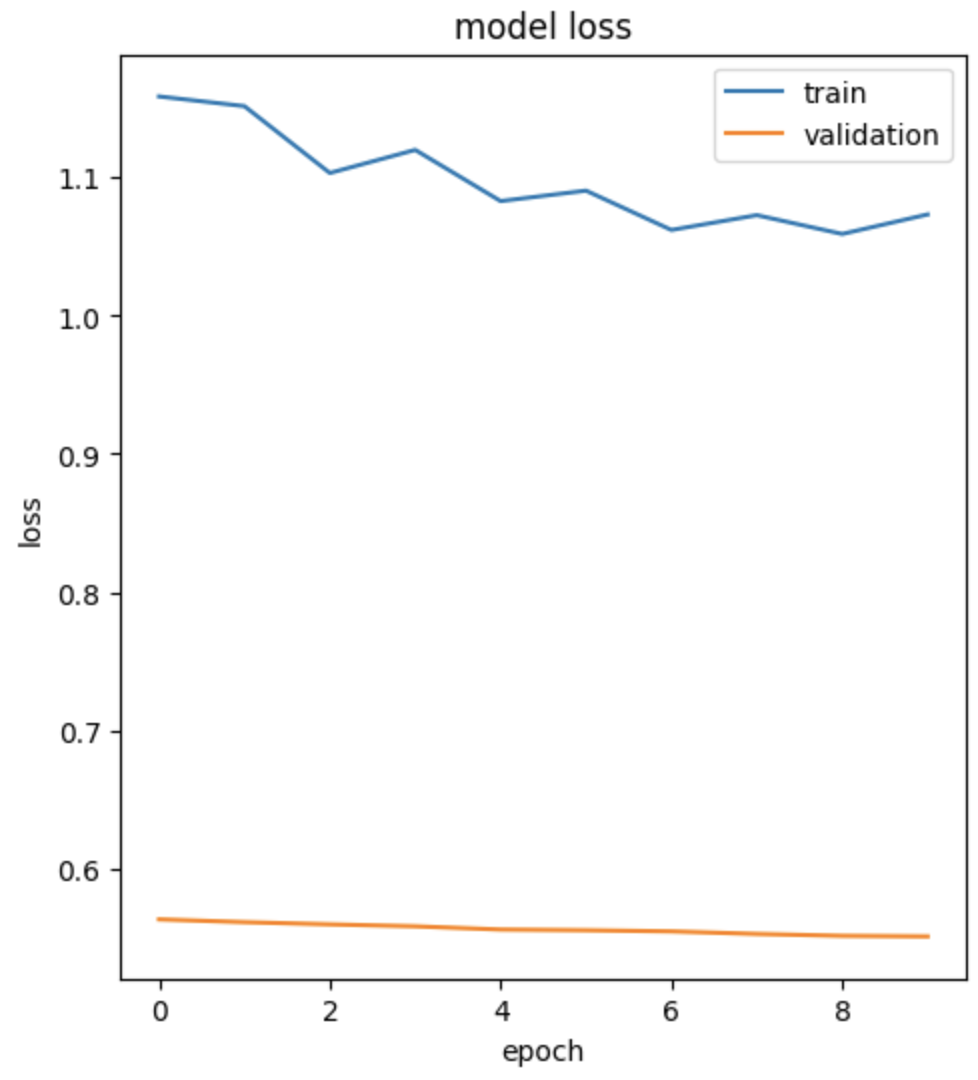

#### Copyright 2023, 2024, 2025 Stephen F Elston. All rights reserved.  